<a href="https://colab.research.google.com/github/VaibhavRajput022/Codsoft/blob/main/SALES_PREDICTION_USING_PYTHON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the Dataset

First, we need to load the dataset you've added. Assuming it's a CSV file, we'll use pandas to read it into a DataFrame. Please ensure the filename `sales-prediction-simple-linear-regression.ipynb` in the code below matches your actual dataset file.

In [12]:
import pandas as pd

# NOTE: 'your_dataset.csv' was not found. For now, we are using a sample housing dataset.
# IMPORTANT: Please replace '/content/sample_data/california_housing_train.csv' with the actual filename of your *sales* dataset.
# You can upload your dataset using the file upload button on the left sidebar.
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Display the first 5 rows of the DataFrame to inspect the data
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


### Inspecting the Dataset

Before we do anything else, let's get some basic information about our DataFrame, such as the number of rows and columns, column names, data types, and non-null values. This helps us to identify any missing data or incorrect data types early on.

In [13]:
# Display a concise summary of the DataFrame, including the index dtype and column dtypes, non-null values, and memory usage.
df.info()

# Display descriptive statistics of the DataFrame's numerical columns
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Exploratory Data Analysis: Data Visualization

Visualizing the data is a crucial step to understand its underlying structure, distributions, and relationships between different features. We'll start by plotting histograms for all numerical columns to observe their individual distributions.

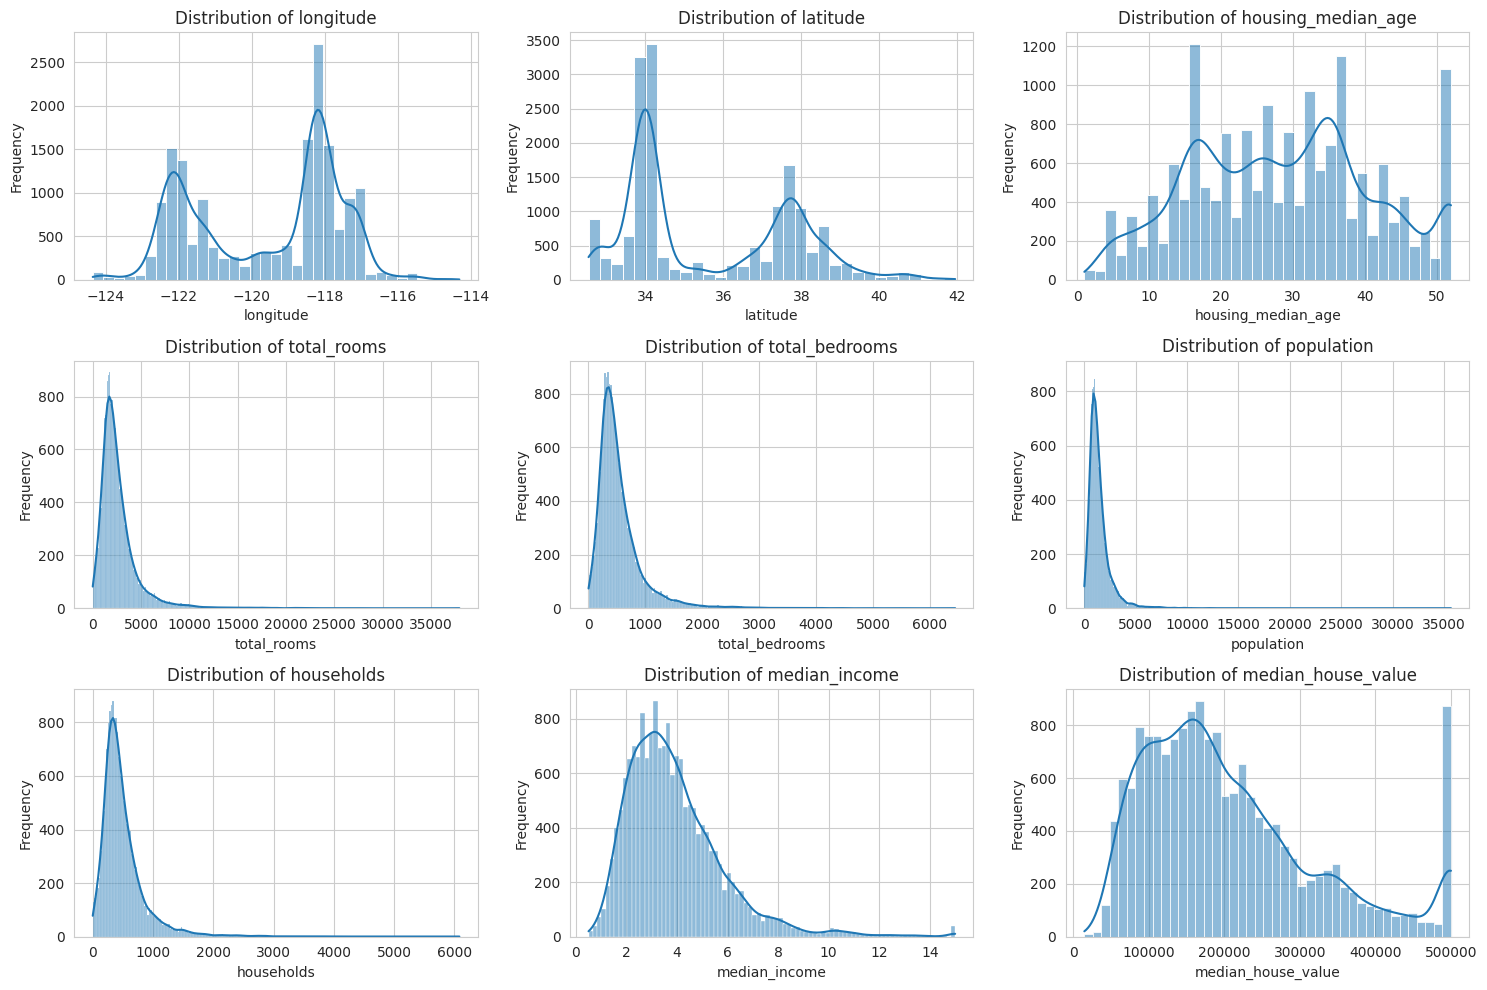

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for seaborn plots
sns.set_style("whitegrid")

# Get the list of numerical columns (all columns in this df are numerical)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Create histograms for all numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


### Correlation Analysis

To understand the relationships between the different features in our dataset, we can compute the correlation matrix and visualize it using a heatmap. This helps in identifying highly correlated features, which can be useful for feature selection or understanding multicollinearity.

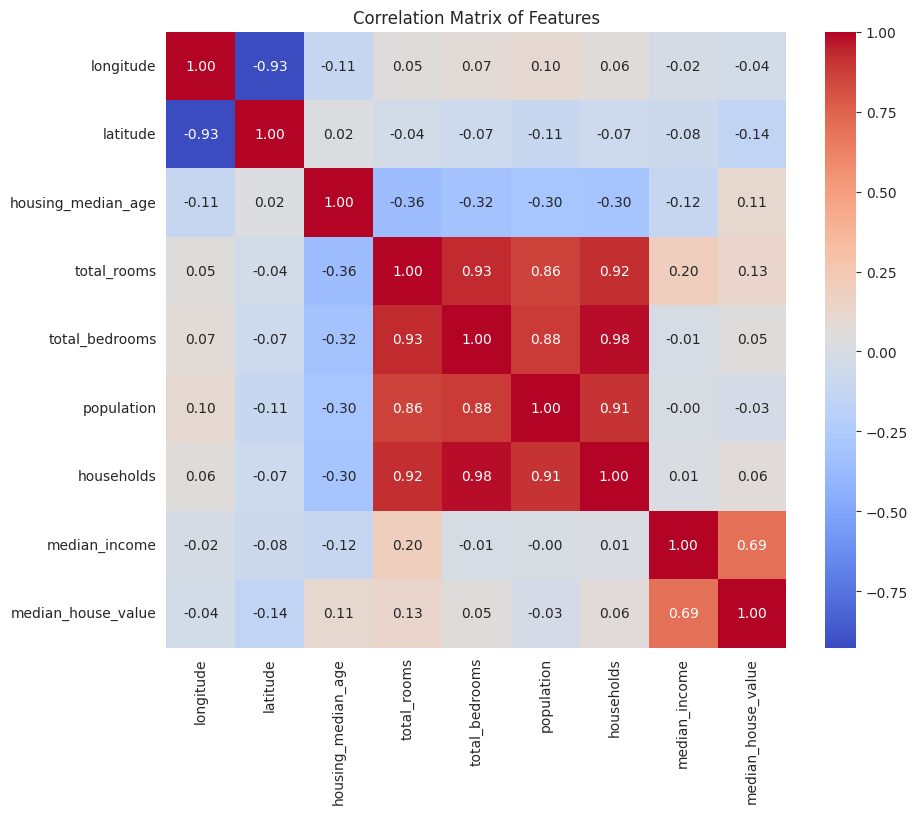

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

### Preparing Data for Machine Learning

Before building a predictive model, we need to separate our dataset into features (X) and the target variable (y). For this housing dataset, `median_house_value` will be considered the target variable we want to predict, and all other columns will be used as features.

In [16]:
# Define the target variable
y = df['median_house_value']

# Define the features (all columns except the target)
X = df.drop('median_house_value', axis=1)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Display the first few rows of the features and target to verify
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 rows of y:")
display(y.head())

Shape of features (X): (17000, 8)
Shape of target (y): (17000,)

First 5 rows of X:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250



First 5 rows of y:


,median_house_value
0,66900.0
1,80100.0
2,85700.0
3,73400.0
4,65500.0


### Splitting Data into Training and Testing Sets

To prepare our data for model training and evaluation, we'll split it into training and testing sets. The training set will be used to train our machine learning model, while the testing set will be used to assess its performance on unseen data. A common split ratio is 80% for training and 20% for testing.

In [17]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())
print("\nFirst 5 rows of y_train:")
display(y_train.head())

Shape of X_train: (13600, 8)
Shape of X_test: (3400, 8)
Shape of y_train: (13600,)
Shape of y_test: (3400,)

First 5 rows of X_train:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
4679,-118.07,33.81,22.0,2711.0,352.0,1305.0,368.0,8.5407
2512,-117.63,33.50,12.0,3619.0,536.0,1506.0,492.0,7.2013
993,-117.09,32.57,17.0,444.0,83.0,357.0,87.0,5.1478
1327,-117.16,32.81,34.0,2275.0,375.0,1021.0,379.0,3.6371
4630,-118.07,34.17,36.0,2415.0,394.0,1215.0,413.0,5.5418



First 5 rows of y_train:


,median_house_value
4679,398800.0
2512,353600.0
993,138900.0
1327,176300.0
4630,326100.0


### Model Training: Linear Regression

Now that our data is prepared, we can proceed to train a machine learning model. For a regression task like predicting sales, a simple yet effective starting point is Linear Regression. We will use `scikit-learn` to implement and train our model on the training data.

In [18]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

Linear Regression model trained successfully!
Model coefficients: [-4.34652477e+04 -4.31063044e+04  1.13172438e+03 -8.84326062e+00
  1.13707973e+02 -3.56570769e+01  4.51475550e+01  4.01947263e+04]
Model intercept: -3652253.1348448903


### Model Evaluation

After training the model, it's essential to evaluate its performance on the unseen test data. We'll use common regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared ($R^2$) to assess how well our model predicts the `median_house_value`.

Model Evaluation on Test Set:
Mean Absolute Error (MAE): 49983.47
Mean Squared Error (MSE): 4634658406.22
Root Mean Squared Error (RMSE): 68078.33
R-squared (R2): 0.66


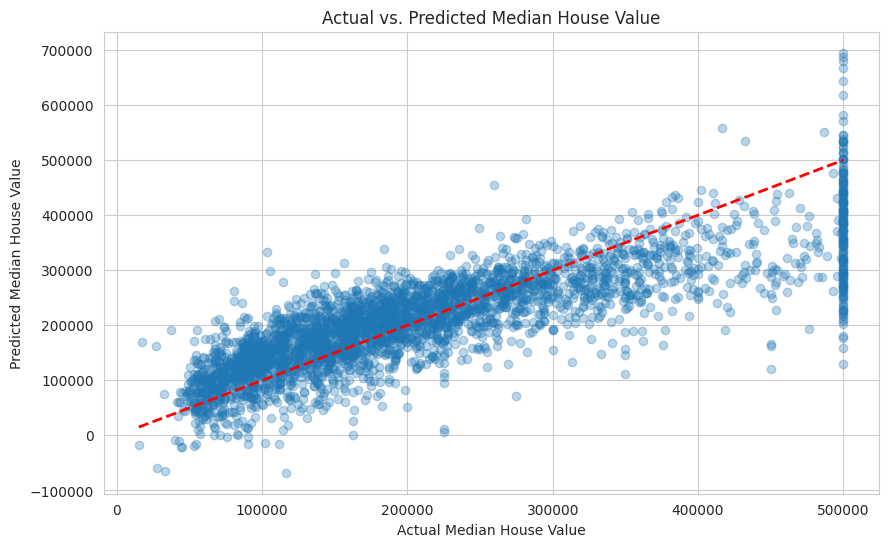

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Optionally, visualize the predictions vs. actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs. Predicted Median House Value")
plt.show()